In [1]:
import torch
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# SET SEED FOR REPRODUCIBILITY
SEED = 10

In [3]:
# READ THE DATASET
df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# CONVERT ALL 0's IN THE TARGET COLUMN TO -1
df.loc[df['Outcome'] == 0, 'Outcome'] = -1

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,-1
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,-1
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# SCALER TO SCALE THE INPUT VALUES IN THE RANGE [-1,1]
scaler = MinMaxScaler(feature_range=(-1, 1))

In [6]:
# GET THE INPUT
x = scaler.fit_transform(df.drop('Outcome', axis=1))
# GET THE OUTPUT
y = df['Outcome'].values

# SPLIT THE DATASET INTO TRAINING AND TEST SET
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=SEED)

# CONVERT DATA TO PYTORCH TENSORS
x_train = torch.tensor(x_train, dtype=torch.float64)
x_test = torch.tensor(x_test, dtype=torch.float64)
y_train = torch.tensor(y_train)
y_test = torch.tensor(y_test)

In [7]:
# LEARNING-RATE / STEP-SIZE
lr = 0.1

# NO. OF ITERATIONS
n_iter = 500

In [8]:
# WEIGHT VECTOR ALSO CONTAINING THE BIAS
# INITIALIZED TO ZERO
w = torch.zeros(x.shape[1]+1, dtype=torch.float64)

In [9]:
# INDICATOR FUNCTION
# IT RETURNS 1 WHEN THE PERCEPTRON MAKES A MISCLASSIFICATION
# OR RETURNS 0 OTHERWISE
def indicator_func(xi,yi,w):
    if yi*(torch.dot(w,xi)) <= 0:
        return 1
    else:
        return 0

In [10]:
# PERCEPTRON LOSS FUNCTION
def loss_func(x,y,w):
    loss = 0

    for i in range(x.shape[0]):
        xi = torch.cat((x[i],torch.tensor([1])),dim=0)
        yi = y[i]
        loss += max(0, -yi*(torch.dot(w,xi)))

    return loss/x.shape[0]

In [11]:
# PERCEPTRON ACCURACY
def acc_func(x,y,w):
    correct = 0

    for i in range(x.shape[0]):
        xi = torch.cat((x[i],torch.tensor([1])),dim=0)
        yi = y[i]

        if yi*(torch.dot(w,xi)) > 0:
            correct += 1

    return correct/x.shape[0]

In [12]:
test_losses = []
test_accs = []

In [13]:
for j in range(n_iter):
    # VECTOR USED TO UPDATE THE WEIGHT VECTOR
    weight_update = torch.zeros_like(w)

    for i in range(x_train.shape[0]):
        # EACH INPUT VECTOR CONCATENATED WITH 1
        xi = torch.cat((x_train[i],torch.tensor([1])),dim=0)
        # TARGET LABEL
        yi = y_train[i]
        # VALUE OF INDICATOR FUNCTION
        ind = indicator_func(xi,yi,w)

        # ADD THE PERCEPTRON UPDATES FOR EACH ITERATION
        weight_update = weight_update + (yi*xi*ind)

    # UPDATE THE WEIGHT VECTOR
    w = w + lr*weight_update

    if j%5 == 0:
        # CALCULATE THE PERCEPTRON LOSS ON THE TEST DATASET
        test_losses.append(loss_func(x_test,y_test,w))

        # CALCULATE THE PERCEPTRON ACCURACY ON THE TEST DATASET
        test_accs.append(acc_func(x_test,y_test,w))

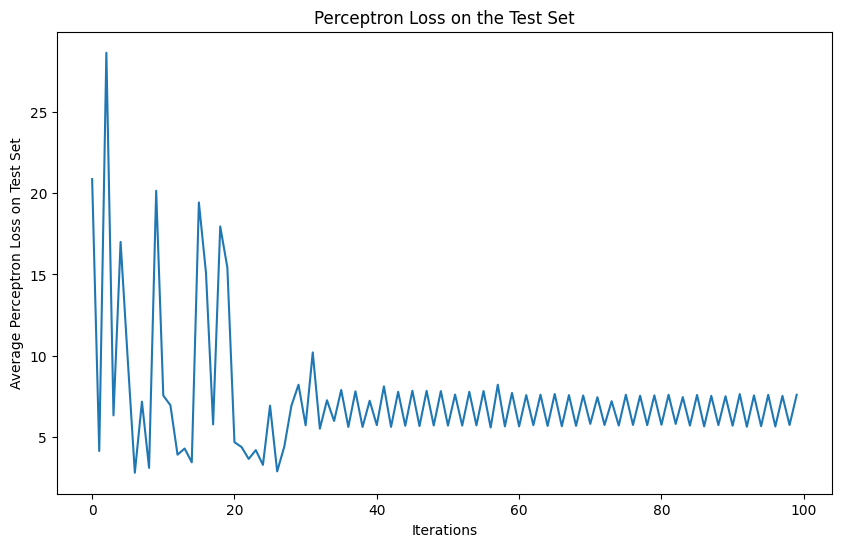

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(test_losses)

plt.xlabel('Iterations')
plt.ylabel('Average Perceptron Loss on Test Set')
plt.title('Perceptron Loss on the Test Set')
plt.show()

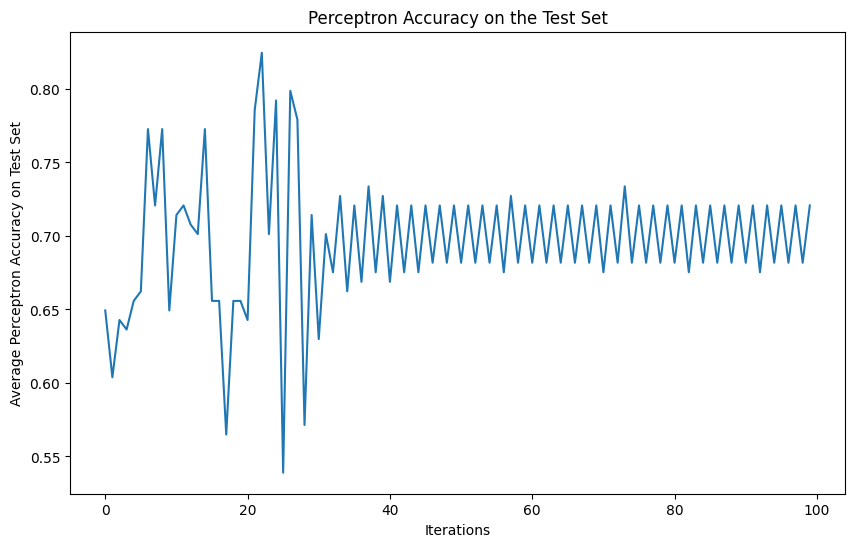

In [15]:
plt.figure(figsize=(10, 6))

plt.plot(test_accs)

plt.xlabel('Iterations')
plt.ylabel('Average Perceptron Accuracy on Test Set')
plt.title('Perceptron Accuracy on the Test Set')
plt.show()

In [16]:
# OUTPUT THE WEIGHT VECTOR
w

tensor([ 23.7059,  59.9075, -14.4213,   3.1616,  -0.1364,  40.2313,  25.8775,
          9.5200, -14.4000], dtype=torch.float64)

POTENTIAL IMPROVEMENTS:-


1.   Remove irrelevant or redundant features
2.   Use different activation functions like relu, sigmoid, tanh
3.   Change learning rate. Use learning rate scheduler
4.   Consider advanced optimizers such as Adam, RNSprop, AdaGrad
5.   Add L1 or L2 Regularization
6.   Consider ensemble methods


**LEARNING RATE SCHEDULING**

In [17]:
# LEARNING-RATE / STEP-SIZE
lr = 0.1

In [18]:
# WEIGHT VECTOR ALSO CONTAINING THE BIAS
# INITIALIZED TO ZERO
w = torch.zeros(x.shape[1]+1, dtype=torch.float64)

In [19]:
test_losses = []
test_accs = []

In [20]:
for j in range(n_iter):
    # VECTOR USED TO UPDATE THE WEIGHT VECTOR
    weight_update = torch.zeros_like(w)

    for i in range(x_train.shape[0]):
        # EACH INPUT VECTOR CONCATENATED WITH 1
        xi = torch.cat((x_train[i],torch.tensor([1])),dim=0)
        # TARGET LABEL
        yi = y_train[i]
        # VALUE OF INDICATOR FUNCTION
        ind = indicator_func(xi,yi,w)

        # ADD THE PERCEPTRON UPDATES FOR EACH ITERATION
        weight_update = weight_update + (yi*xi*ind)

    # UPDATE THE WEIGHT VECTOR
    w = w + lr*weight_update

    if j%200 == 0:
        lr = lr*0.1

    if j%5 == 0:
        # CALCULATE THE PERCEPTRON LOSS ON THE TEST DATASET
        test_losses.append(loss_func(x_test,y_test,w))

        # CALCULATE THE PERCEPTRON ACCURACY ON THE TEST DATASET
        test_accs.append(acc_func(x_test,y_test,w))

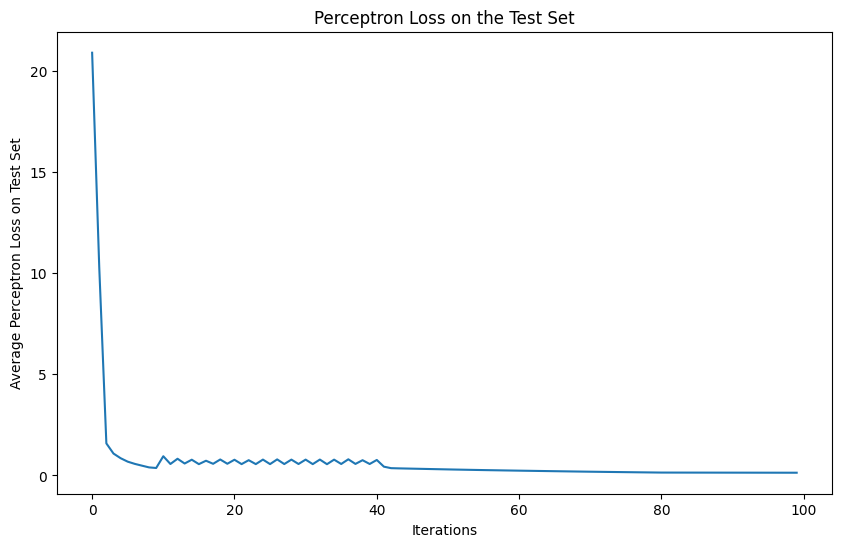

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(test_losses)

plt.xlabel('Iterations')
plt.ylabel('Average Perceptron Loss on Test Set')
plt.title('Perceptron Loss on the Test Set')
plt.show()

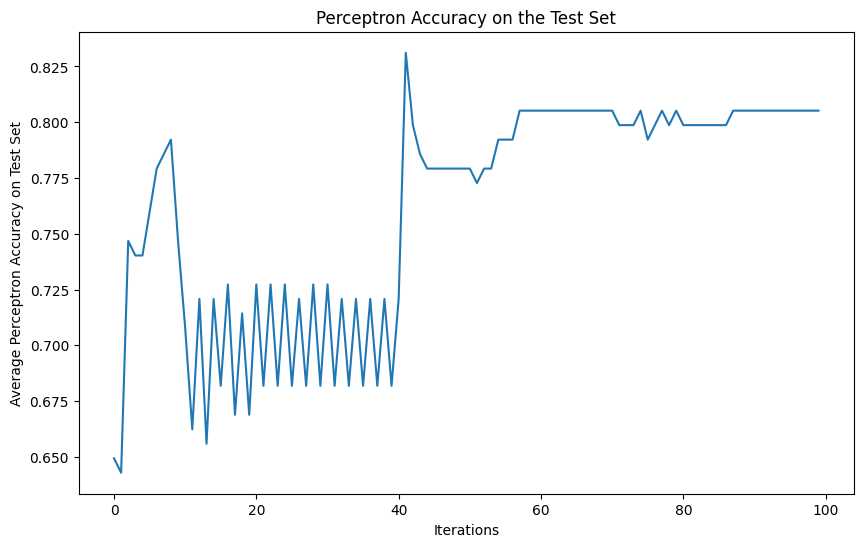

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(test_accs)

plt.xlabel('Iterations')
plt.ylabel('Average Perceptron Accuracy on Test Set')
plt.title('Perceptron Accuracy on the Test Set')
plt.show()

In [23]:
# OUTPUT THE WEIGHT VECTOR
w

tensor([ 0.7240,  2.4016, -0.7232,  0.0537, -1.0554,  2.2944,  0.8411, -0.2582,
        -0.5895], dtype=torch.float64)